## ReAct Architecture Basic ChatBot

In [9]:
import os
from dotenv import load_dotenv
from langchain_tavily import TavilySearch
from langchain_groq import ChatGroq
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import Image, display

load_dotenv()


True

In [2]:
## Custom  function
def multiply(a:int, b:int) -> int:
    """
    Multiplies two numbers

    Args:
        a (int): The first int
        b (int): The second int

    Returns:
        int: Output int
    """
    return a * b

def addition(a:int, b:int) -> int:
    """
    Adds two numbers

    Args:
        a (int): The first int
        b (int): The second int

    Returns:
        int: Output int
    """
    return a + b

tavilyTool = TavilySearch(max_results = 3)
tools = [tavilyTool, multiply, addition]

In [3]:

## State definition for the graph
class State(TypedDict):
    messages: Annotated[list, add_messages]


In [4]:
llm = ChatGroq(model_name = "llama-3.1-8b-instant")
llm_with_tools = llm.bind_tools(tools)

In [5]:
def tool_calling_node(state: State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

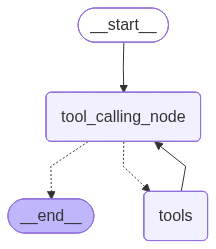

In [10]:
graph_builder = StateGraph(State)
graph_builder.add_node("tool_calling_node", tool_calling_node)
graph_builder.add_node("tools", ToolNode(tools))


graph_builder.add_edge(START, "tool_calling_node")
graph_builder.add_conditional_edges(
    "tool_calling_node",
    # If the latest message (result) from llm is a tool call -> go to tool_container_node
    # If the latest message (result) from llm is not a tool call -> go to END
    tools_condition,
    ["tools", END]
)
graph_builder.add_edge("tools", "tool_calling_node")

tool_graph = graph_builder.compile()

try: 
    display(Image(tool_graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)
    pass

In [17]:
response = tool_graph.invoke({"messages": "What is the recent price of Bitcoin and what is the current price of Ethereum and out of them both which one had the most price fluctutation today"})

In [18]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the recent price of Bitcoin and what is the current price of Ethereum and out of them both which one had the most price fluctutation today
================================== Ai Message ==================================
Tool Calls:
  tavily_search (86mb3mhrk)
 Call ID: 86mb3mhrk
  Args:
    query: Bitcoin recent price
    search_depth: advanced
    topic: finance
  tavily_search (0x2bhwch7)
 Call ID: 0x2bhwch7
  Args:
    query: Ethereum current price
    search_depth: advanced
    topic: finance
  tavily_search (8wq0q62z0)
 Call ID: 8wq0q62z0
  Args:
    query: Bitcoin price fluctuation today vs Ethereum
    search_depth: advanced
    topic: finance
================================= Tool Message =================================
Name: tavily_search

{"query": "Bitcoin recent price", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://uk.finance.yahoo.com/quote/

### Adding Memory to the Agent

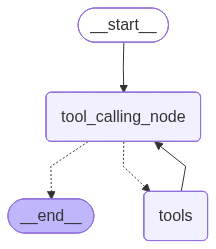

In [ ]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

graph_builder = StateGraph(State)
graph_builder.add_node("tool_calling_node", tool_calling_node)
graph_builder.add_node("tools", ToolNode(tools))


graph_builder.add_edge(START, "tool_calling_node")
graph_builder.add_conditional_edges(
    "tool_calling_node",
    # If the latest message (result) from llm is a tool call -> go to tool_container_node
    # If the latest message (result) from llm is not a tool call -> go to END
    tools_condition,
    ["tools", END]
)
graph_builder.add_edge("tools", "tool_calling_node")

tool_graph = graph_builder.compile(checkpointer=memory)

try: 
    display(Image(tool_graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)
    pass

In [21]:
config = {"configurable": {"thread_id": "thread_1"}}

response = tool_graph.invoke({"messages": "Hello my name is Suyog and I am 23 years old."}, config=config)

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Suyog and I am 23 years old.
================================== Ai Message ==================================

It's nice to meet you, Suyog! I'm happy to chat with you. What would you like to talk about?


In [22]:
response = tool_graph.invoke({"messages": "Hey there what is my name and how old am I?"}, config=config)

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Suyog and I am 23 years old.
================================== Ai Message ==================================

It's nice to meet you, Suyog! I'm happy to chat with you. What would you like to talk about?
================================ Human Message =================================

Hey there what is my name and how old am I?
================================== Ai Message ==================================

Your name is Suyog and you are 23 years old.


In [23]:
response = tool_graph.invoke({"messages": "How old would I be 34 years from now?"}, config=config)

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Suyog and I am 23 years old.
================================== Ai Message ==================================

It's nice to meet you, Suyog! I'm happy to chat with you. What would you like to talk about?
================================ Human Message =================================

Hey there what is my name and how old am I?
================================== Ai Message ==================================

Your name is Suyog and you are 23 years old.
================================ Human Message =================================

How old would I be 34 years from now?
================================== Ai Message ==================================
Tool Calls:
  addition (hfx85hv4g)
 Call ID: hfx85hv4g
  Args:
    a: 23
    b: 34
================================= Tool Message =================================
Name: addition

57
================================== Ai Message ==============

In [24]:
response = tool_graph.invoke({"messages": "What is the product of my age and 2"}, config=config)

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Suyog and I am 23 years old.
================================== Ai Message ==================================

It's nice to meet you, Suyog! I'm happy to chat with you. What would you like to talk about?
================================ Human Message =================================

Hey there what is my name and how old am I?
================================== Ai Message ==================================

Your name is Suyog and you are 23 years old.
================================ Human Message =================================

How old would I be 34 years from now?
================================== Ai Message ==================================
Tool Calls:
  addition (hfx85hv4g)
 Call ID: hfx85hv4g
  Args:
    a: 23
    b: 34
================================= Tool Message =================================
Name: addition

57
================================== Ai Message ==============

### Streaming in LangGraph


In [26]:
def superBot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}
    
memory = MemorySaver()

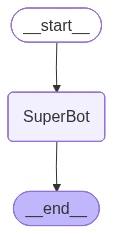

In [30]:
graph = StateGraph(State)
graph.add_node("SuperBot", superBot)
graph.add_edge(START, "SuperBot")
graph.add_edge("SuperBot", END)

graph_builder = graph.compile(checkpointer=memory)

try: 
    display(Image(graph_builder.get_graph().draw_mermaid_png()))
except:
    pass

In [32]:
config = {"configurable":{"thread_id": "1"}}

graph_builder.invoke({"messages": "Hello My name is Mogambo and I love to drink coffee."}, config=config)


{'messages': [HumanMessage(content='Hello, how are you?', additional_kwargs={}, response_metadata={}, id='fde25bfc-167c-4e5e-a51f-fe0b68458969'),
  AIMessage(content="I'm functioning properly, thank you for asking. I'm a large language model, so I don't have emotions or feelings like humans do, but I'm here to assist you with any questions or information you might need. Is there something specific you'd like to talk about or ask?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 41, 'total_tokens': 100, 'completion_time': 0.087272888, 'completion_tokens_details': None, 'prompt_time': 0.004905429, 'prompt_tokens_details': None, 'queue_time': 0.151949131, 'total_time': 0.092178317}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e09ee421cf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cbbe3-aa5f-7be3-bbc5-a5b0554505ac-0', tool_calls=[], invalid_tool_ca

In [33]:
config = {"configurable":{"thread_id": "2"}}

for chunk in graph_builder.stream({"messages": "Hello My name is Mogambo and I love to drink coffee."}, config=config, stream_mode="updates"):
    print(chunk)



{'SuperBot': {'messages': [AIMessage(content="Nice to meet you, Mogambo. It sounds like you're a coffee lover. What's your go-to coffee order or brewing method? Do you prefer a strong espresso, a rich French roast, or a smooth cappuccino?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 49, 'total_tokens': 99, 'completion_time': 0.075644729, 'completion_tokens_details': None, 'prompt_time': 0.003030095, 'prompt_tokens_details': None, 'queue_time': 0.005590837, 'total_time': 0.078674824}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e2c608b1d6', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cbbe9-7a5d-7d80-9222-100eb73fa645-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 49, 'output_tokens': 50, 'total_tokens': 99})]}}


In [34]:
for chunk in graph_builder.stream({"messages": "Hello My name is Mogambo and I love to drink coffee."}, config=config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hello My name is Mogambo and I love to drink coffee.', additional_kwargs={}, response_metadata={}, id='ee74c317-45e1-4df7-a1c1-9030ee208298'), AIMessage(content="Nice to meet you, Mogambo. It sounds like you're a coffee lover. What's your go-to coffee order or brewing method? Do you prefer a strong espresso, a rich French roast, or a smooth cappuccino?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 49, 'total_tokens': 99, 'completion_time': 0.075644729, 'completion_tokens_details': None, 'prompt_time': 0.003030095, 'prompt_tokens_details': None, 'queue_time': 0.005590837, 'total_time': 0.078674824}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e2c608b1d6', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cbbe9-7a5d-7d80-9222-100eb73fa645-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 49, 

In [35]:
for chunk in graph_builder.stream({"messages": "Hello Tell me what is my favoritte drink?"}, config=config, stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Mogambo, I think I can make an educated guess. Based on our previous conversation, I believe your favorite drink is coffee. Am I correct?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 180, 'total_tokens': 213, 'completion_time': 0.041953595, 'completion_tokens_details': None, 'prompt_time': 0.010148627, 'prompt_tokens_details': None, 'queue_time': 0.005410811, 'total_time': 0.052102222}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_020e283281', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cbbeb-8055-77e1-92c0-b003e45ccdef-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 180, 'output_tokens': 33, 'total_tokens': 213})]}}


In [36]:
for chunk in graph_builder.stream({"messages": "I also like to drink tea"}, config=config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hello My name is Mogambo and I love to drink coffee.', additional_kwargs={}, response_metadata={}, id='ee74c317-45e1-4df7-a1c1-9030ee208298'), AIMessage(content="Nice to meet you, Mogambo. It sounds like you're a coffee lover. What's your go-to coffee order or brewing method? Do you prefer a strong espresso, a rich French roast, or a smooth cappuccino?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 49, 'total_tokens': 99, 'completion_time': 0.075644729, 'completion_tokens_details': None, 'prompt_time': 0.003030095, 'prompt_tokens_details': None, 'queue_time': 0.005590837, 'total_time': 0.078674824}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e2c608b1d6', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cbbe9-7a5d-7d80-9222-100eb73fa645-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 49, 

### Astream Method

In [37]:
config = {"configurable":{"thread_id": "4"}}

async def stream_output():

    async for event in graph_builder.astream_events({"messages": "Hello My name is Mogambo and I love to drink coffee."}, config=config, version="v2"):
        print(event)


await stream_output()


{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hello My name is Mogambo and I love to drink coffee.'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019cbbf1-7dd3-7ed3-baa4-fe872317f3d9', 'metadata': {'thread_id': '4'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hello My name is Mogambo and I love to drink coffee.', additional_kwargs={}, response_metadata={}, id='0fa6e27b-62ab-4c7c-ad03-2852f908928a')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '019cbbf1-7dd5-79b2-ab9d-f821f2e100b7', 'metadata': {'thread_id': '4', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:c8eed3f8-377e-3cc8-a6e1-1c6d93df9217'}, 'parent_ids': ['019cbbf1-7dd3-7ed3-baa4-fe872317f3d9']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(content='Hello My name is Mogambo an